In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_rows = 1200

customer_ids = [f"CUST_{i:04d}" for i in range(1, n_rows + 1)]
ages = np.random.randint(18, 70, size=n_rows).astype(float)
genders = np.random.choice(["Male", "Female", "Other", "male", "Female ", "OTHER "], size=n_rows, p=[0.4, 0.4, 0.05, 0.05, 0.05, 0.05])
annual_income = np.random.normal(60000, 22000, size=n_rows).astype(float)
spending_score = np.random.randint(1, 101, size=n_rows).astype(float)
purchase_frequency = np.random.randint(1, 35, size=n_rows)
product_category = np.random.choice(
    ["Electronics", "Clothing", "Home & Kitchen", "Beauty", "Sports", " electronics", "clothing "],
    size=n_rows,
    p=[0.2, 0.3, 0.2, 0.1, 0.1, 0.05, 0.05]
)
total_spent = (spending_score * purchase_frequency * np.random.uniform(0.8, 1.8, size=n_rows))
membership_level = np.random.choice(["Bronze", "Silver", "Gold", "Platinum"], size=n_rows, p=[0.4, 0.3, 0.2, 0.1])

df = pd.DataFrame({
    "CustomerID": customer_ids,
    "Age": ages,
    "Gender": genders,
    "AnnualIncome": annual_income,
    "SpendingScore": spending_score,
    "PurchaseFrequency": purchase_frequency,
    "PreferredCategory": product_category,
    "TotalSpent": total_spent,
    "MembershipLevel": membership_level
})

# 1. Inject Missing Values (NaNs)
df.loc[np.random.choice(df.index, 50), 'AnnualIncome'] = np.nan
df.loc[np.random.choice(df.index, 30), 'Age'] = np.nan
df.loc[np.random.choice(df.index, 40), 'PreferredCategory'] = np.nan

# 2. Inject Outliers / Invalid values
df.loc[15, 'Age'] = 150           # Unrealistic age
df.loc[42, 'AnnualIncome'] = -50000 # Negative income
df.loc[100, 'SpendingScore'] = 150  # Invalid score (> 100)

# 3. Inject Duplicate Rows
df = pd.concat([df, df.sample(35, random_state=42)], ignore_index=True)

# Save to CSV
df.to_csv("messy_retail_customers.csv", index=False)
print(f"Messy dataset generated with {len(df)} rows (includes duplicates, NaNs, and outliers).")

Messy dataset generated with 1235 rows (includes duplicates, NaNs, and outliers).


In [3]:
df

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseFrequency,PreferredCategory,TotalSpent,MembershipLevel
0,CUST_0001,56.0,Female,70025.172711,87.0,7,Home & Kitchen,633.452322,Silver
1,CUST_0002,69.0,Female,36202.537529,41.0,11,Clothing,506.709601,Bronze
2,CUST_0003,46.0,Female,30790.250293,59.0,4,Home & Kitchen,232.179842,Bronze
3,CUST_0004,32.0,OTHER,59651.966374,89.0,25,Home & Kitchen,3063.682874,Gold
4,CUST_0005,60.0,Female,78702.067765,54.0,12,Home & Kitchen,618.737224,Silver
...,...,...,...,...,...,...,...,...,...
1230,CUST_0391,69.0,male,32684.443164,37.0,25,Clothing,1436.272602,Silver
1231,CUST_0894,55.0,Male,75346.905208,35.0,20,Electronics,982.803498,Silver
1232,CUST_0693,55.0,Male,58139.614019,73.0,13,Home & Kitchen,1010.955550,Silver
1233,CUST_0728,20.0,Male,49431.695198,73.0,14,Clothing,1107.344348,Silver


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1235 non-null   object 
 1   Age                1204 non-null   float64
 2   Gender             1235 non-null   object 
 3   AnnualIncome       1186 non-null   float64
 4   SpendingScore      1235 non-null   float64
 5   PurchaseFrequency  1235 non-null   int32  
 6   PreferredCategory  1196 non-null   object 
 7   TotalSpent         1235 non-null   float64
 8   MembershipLevel    1235 non-null   object 
dtypes: float64(4), int32(1), object(4)
memory usage: 82.1+ KB


In [5]:
df.isnull().sum()

CustomerID            0
Age                  31
Gender                0
AnnualIncome         49
SpendingScore         0
PurchaseFrequency     0
PreferredCategory    39
TotalSpent            0
MembershipLevel       0
dtype: int64

In [6]:
df.describe().round()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TotalSpent
count,1204.0,1186.0,1235.0,1235.0,1235.0
mean,44.0,60441.0,51.0,18.0,1166.0
std,15.0,21701.0,29.0,10.0,1020.0
min,18.0,-50000.0,1.0,1.0,3.0
25%,31.0,45645.0,26.0,10.0,340.0
50%,44.0,60994.0,52.0,18.0,890.0
75%,56.0,75109.0,76.0,26.0,1731.0
max,150.0,136909.0,150.0,34.0,5940.0


In [7]:
df.shape

(1235, 9)

In [8]:
df.isnull().sum()/len(df)*100

CustomerID           0.000000
Age                  2.510121
Gender               0.000000
AnnualIncome         3.967611
SpendingScore        0.000000
PurchaseFrequency    0.000000
PreferredCategory    3.157895
TotalSpent           0.000000
MembershipLevel      0.000000
dtype: float64

In [9]:
df[df.duplicated()].shape

(35, 9)

In [10]:
df["AnnualIncome"].value_counts().head(5)

AnnualIncome
71437.026744    2
79453.330727    2
67691.089986    2
47702.115987    2
58081.256835    2
Name: count, dtype: int64

In [11]:
df[df["AnnualIncome"]=="59651.966374"]

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseFrequency,PreferredCategory,TotalSpent,MembershipLevel


In [12]:
for col in df.columns:
    if df[col].nunique()<59651.966374:
        print(df[col].value_counts())
        print("-"*50)

CustomerID
CUST_0610    2
CUST_0850    2
CUST_0866    2
CUST_0424    2
CUST_0571    2
            ..
CUST_0407    1
CUST_0406    1
CUST_0405    1
CUST_0404    1
CUST_1200    1
Name: count, Length: 1200, dtype: int64
--------------------------------------------------
Age
52.0     36
43.0     35
50.0     32
68.0     30
54.0     30
45.0     30
66.0     29
18.0     28
42.0     28
25.0     27
22.0     27
64.0     26
20.0     26
49.0     26
19.0     26
62.0     25
61.0     25
56.0     25
40.0     25
47.0     24
23.0     24
57.0     24
34.0     24
41.0     24
29.0     23
31.0     23
53.0     23
28.0     23
46.0     22
69.0     22
65.0     22
21.0     21
36.0     21
38.0     21
32.0     21
26.0     21
33.0     21
55.0     20
59.0     20
39.0     20
51.0     20
27.0     20
58.0     19
30.0     19
67.0     17
37.0     17
35.0     17
44.0     17
48.0     16
24.0     16
63.0     13
60.0     12
150.0     1
Name: count, dtype: int64
--------------------------------------------------
Gender
Female   

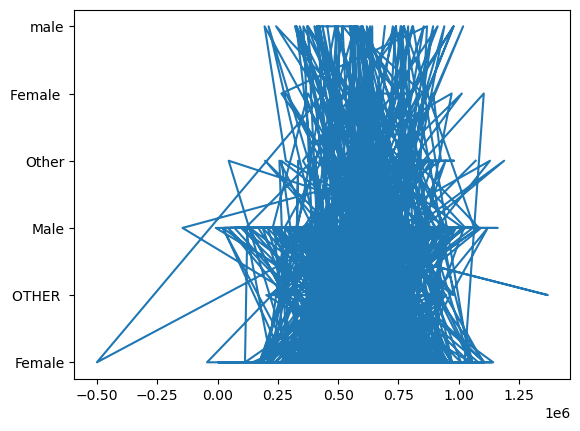

In [17]:
import matplotlib.pyplot as plt
a=df["AnnualIncome"]*10
x=a
y=df["Gender"]
plt.plot(x,y)
plt.show()

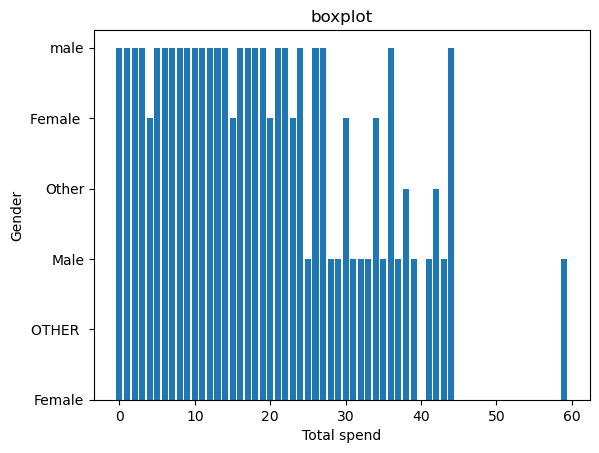

In [29]:
import matplotlib.pyplot as plt
x=df["TotalSpent"]//100
y=df["Gender"]

plt.bar(x,y)
plt.title("boxplot")
plt.xlabel("Total spend")
plt.ylabel("Gender")
plt.show()

In [43]:
print("Harshit".split())

['Harshit']


In [90]:
a="ha"
b=1234
userid=print(input("Enter the user id:"))
psd=print(input("Enter the password:"))
if userid==a:
    pass
elif psd==b:
    print("Login Successfully.")
else:
   print("Login Again")


  

Enter the user id: ha


ha


Enter the password: 1234


1234
Login Again
